            USO_Close  USO_MA5
date                          
2018-01-02      12.10      NaN
2018-01-03      12.10      NaN
2018-01-04      12.14      NaN
2018-01-05      12.23      NaN
2018-01-08      12.23   12.160
2018-01-09      12.22   12.184
2018-01-10      12.31   12.226
2018-01-11      12.36   12.270
2018-01-12      12.34   12.292
2018-01-15      12.38   12.322


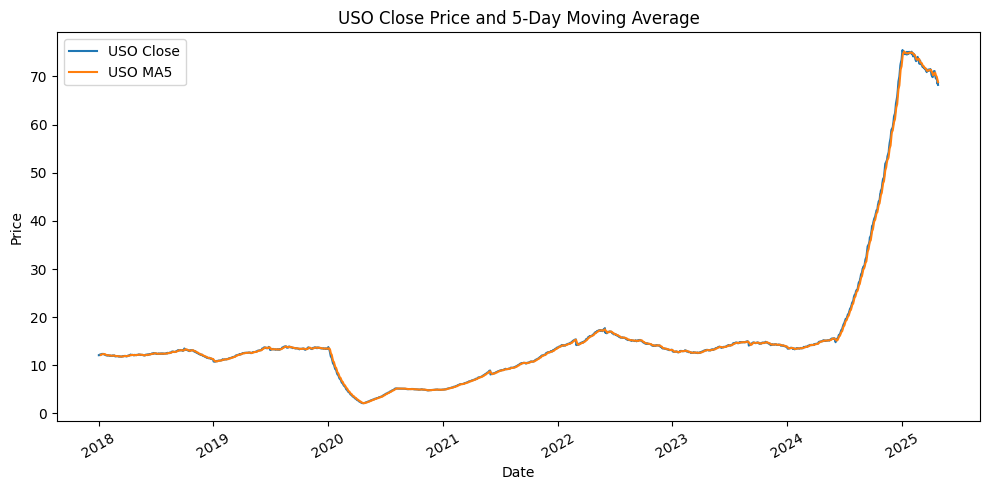

In [1]:
# ==============================
# TACO 第三次课 示例 3
# 计算 USO 的 5 日均线
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("market_data_2018_2025.csv", parse_dates=["date"])
df = df.set_index("date")

# 计算 USO 的 5 日移动平均线
# rolling(5) 表示每次取最近 5 天
# mean() 表示计算平均值
df["USO_MA5"] = df["USO_Close"].rolling(5).mean()

# 查看结果
print(df[["USO_Close", "USO_MA5"]].head(10))

# 画图
plt.figure(figsize=(10, 5))

# 原始收盘价
plt.plot(df.index, df["USO_Close"], label="USO Close")

# 5 日均线
plt.plot(df.index, df["USO_MA5"], label="USO MA5")

plt.title("USO Close Price and 5-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

多资产价格数据：
            USO_Close  GLD_Close  SPY_Close
date                                       
2018-01-02      12.10     125.20     268.00
2018-01-03      12.10     125.74     268.73
2018-01-04      12.14     125.37     268.22
2018-01-05      12.23     124.53     267.95
2018-01-08      12.23     124.36     266.66


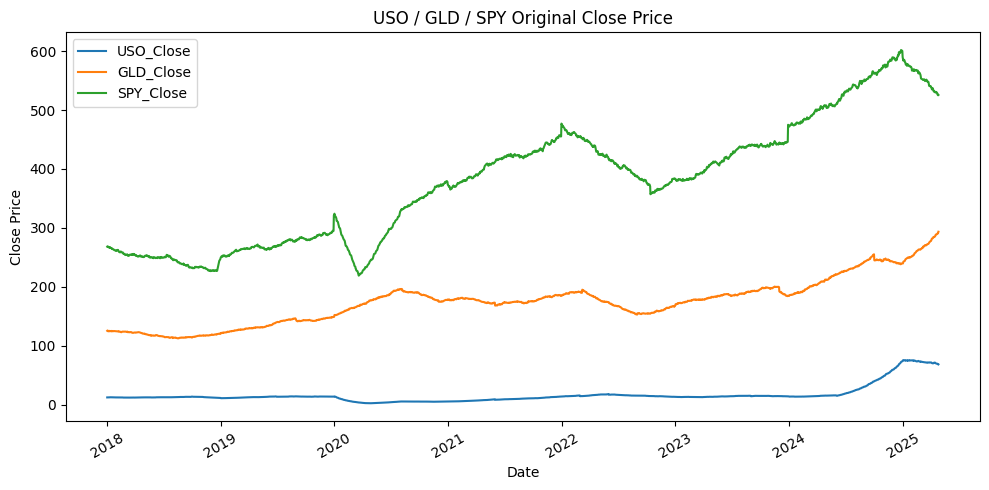

In [2]:
# ==============================
# TACO 第三次课 示例 4
# 多资产原始价格对比图
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("market_data_2018_2025.csv", parse_dates=["date"])
df = df.set_index("date")

# 只选择需要对比的资产
price_df = df[["USO_Close", "GLD_Close", "SPY_Close"]]

print("多资产价格数据：")
print(price_df.head())

plt.figure(figsize=(10, 5))

# 依次绘制每一列
for column in price_df.columns:
    plt.plot(price_df.index, price_df[column], label=column)

plt.title("USO / GLD / SPY Original Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

归一化后的数据：
             USO_Close   GLD_Close   SPY_Close
date                                          
2018-01-02  100.000000  100.000000  100.000000
2018-01-03  100.000000  100.431310  100.272388
2018-01-04  100.330579  100.135783  100.082090
2018-01-05  101.074380   99.464856   99.981343
2018-01-08  101.074380   99.329073   99.500000


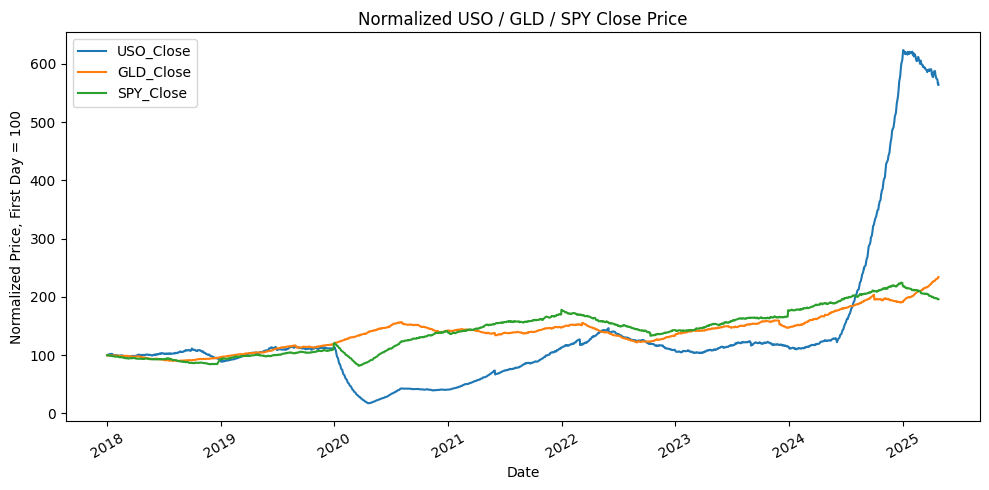

In [3]:
# ==============================
# TACO 第三次课 示例 5
# 多资产归一化对比图
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("market_data_2018_2025.csv", parse_dates=["date"])
df = df.set_index("date")

# 选择三个资产的收盘价
price_df = df[["USO_Close", "GLD_Close", "SPY_Close"]]

# 删除空值，避免第一天数据为空影响归一化
price_df = price_df.dropna()

# 归一化处理
# 每一列都除以这一列第一天的价格，再乘以 100
price_norm = price_df / price_df.iloc[0] * 100

print("归一化后的数据：")
print(price_norm.head())

# 画归一化后的多资产图
plt.figure(figsize=(10, 5))

for column in price_norm.columns:
    plt.plot(price_norm.index, price_norm[column], label=column)

plt.title("Normalized USO / GLD / SPY Close Price")
plt.xlabel("Date")
plt.ylabel("Normalized Price, First Day = 100")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

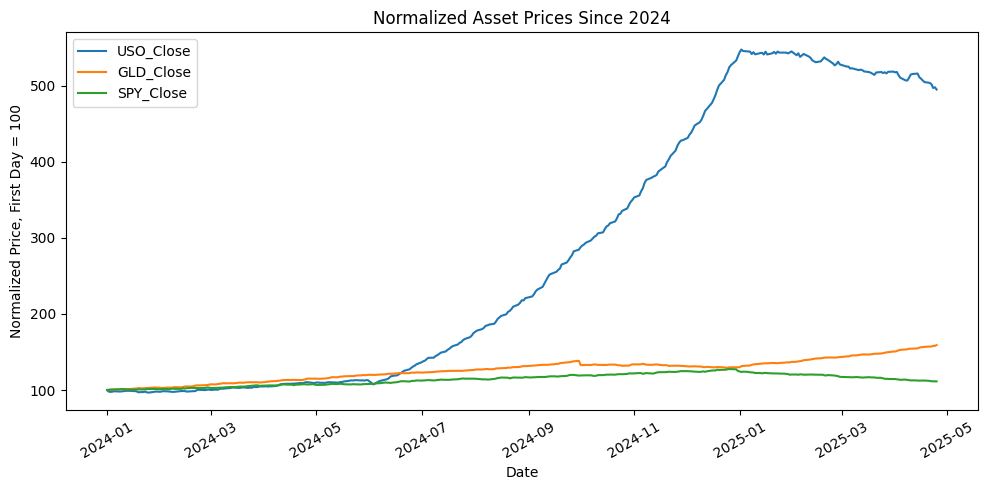

In [4]:
# ==============================
# TACO 第三次课 示例 6
# 按日期筛选数据
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("market_data_2018_2025.csv", parse_dates=["date"])
df = df.set_index("date")

# 筛选 2024 年之后的数据
df_recent = df[df.index >= "2024-01-01"]

price_df = df_recent[["USO_Close", "GLD_Close", "SPY_Close"]]
price_df = price_df.dropna()

# 归一化
price_norm = price_df / price_df.iloc[0] * 100

plt.figure(figsize=(10, 5))

for column in price_norm.columns:
    plt.plot(price_norm.index, price_norm[column], label=column)

plt.title("Normalized Asset Prices Since 2024")
plt.xlabel("Date")
plt.ylabel("Normalized Price, First Day = 100")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

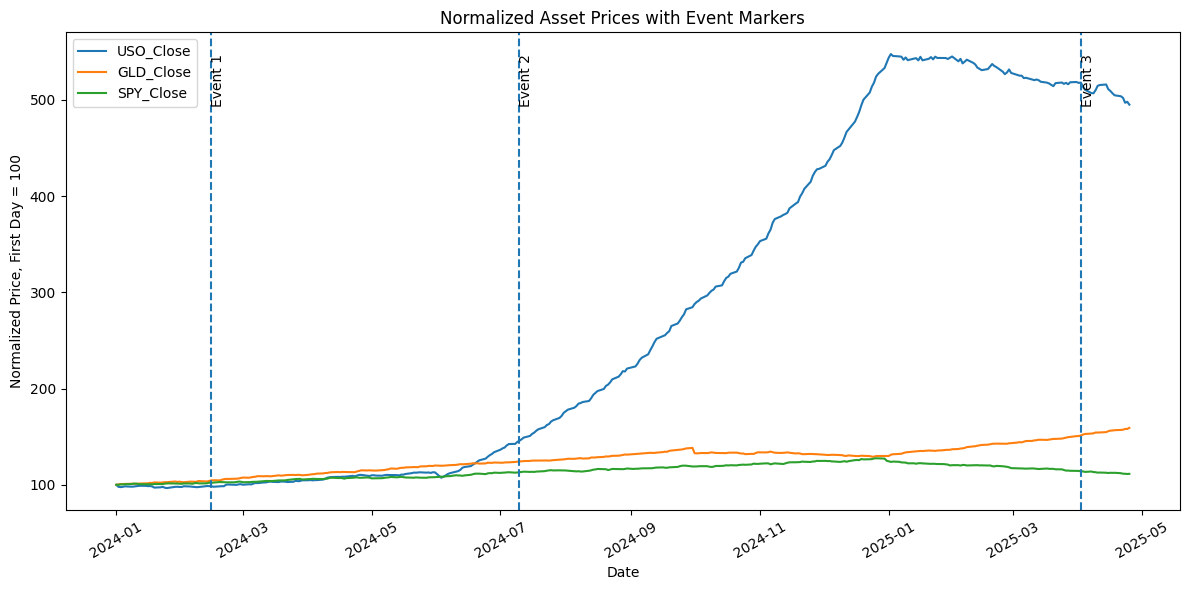

In [5]:
# ==============================
# TACO 第三次课 示例 7
# 在图上标注事件日期
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("market_data_2018_2025.csv", parse_dates=["date"])
df = df.set_index("date")

# 为了图更清楚，这里只看 2024 年之后
df_recent = df[df.index >= "2024-01-01"]

price_df = df_recent[["USO_Close", "GLD_Close", "SPY_Close"]].dropna()

# 归一化
price_norm = price_df / price_df.iloc[0] * 100

# 示例事件日期
# 实际课堂中可以替换成老师提供的 TACO 事件日期
events = {
    "Event 1": "2024-02-15",
    "Event 2": "2024-07-10",
    "Event 3": "2025-04-02"
}

plt.figure(figsize=(12, 6))

# 画归一化后的资产价格
for column in price_norm.columns:
    plt.plot(price_norm.index, price_norm[column], label=column)

# 标注事件日期
for event_name, event_date in events.items():
    event_date = pd.to_datetime(event_date)

    # 画竖线
    plt.axvline(x=event_date, linestyle="--")

    # 添加文字说明
    plt.text(
        event_date,
        price_norm.max().max(),
        event_name,
        rotation=90,
        verticalalignment="top"
    )

plt.title("Normalized Asset Prices with Event Markers")
plt.xlabel("Date")
plt.ylabel("Normalized Price, First Day = 100")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [6]:
# ==============================
# TACO 第三次课 示例 8
# 计算事件后 1 天、3 天、5 天涨跌幅
# ==============================

import pandas as pd

# 读取数据
df = pd.read_csv("market_data_2018_2025.csv", parse_dates=["date"])
df = df.set_index("date")

# 只保留需要计算的资产
price_df = df[["USO_Close", "GLD_Close", "SPY_Close"]].dropna()

# 准备事件日期
events = {
    "Event 1": "2024-02-15",
    "Event 2": "2024-07-10",
    "Event 3": "2025-04-02"
}

# 需要观察的窗口：事件后 1 天、3 天、5 天
windows = [1, 3, 5]

# 用来保存结果
results = []

# 遍历每个事件
for event_name, event_date in events.items():
    # 转换为日期格式
    event_date = pd.to_datetime(event_date)

    # 如果事件日期不是交易日，就找到它之后最近的一个交易日
    # price_df.index >= event_date 会筛选出事件日期之后的所有交易日
    future_dates = price_df.index[price_df.index >= event_date]

    # 如果没有找到未来交易日，跳过这个事件
    if len(future_dates) == 0:
        print(f"{event_name} 没有可用交易日数据，跳过。")
        continue

    # 事件对应的交易日
    event_trade_date = future_dates[0]

    # 事件当天价格
    base_prices = price_df.loc[event_trade_date]

    # 遍历 1 天、3 天、5 天
    for window in windows:
        # 找到事件交易日在索引中的位置
        event_position = price_df.index.get_loc(event_trade_date)

        # 计算目标日期的位置
        target_position = event_position + window

        # 如果目标位置超过数据范围，就跳过
        if target_position >= len(price_df):
            continue

        # 获取目标交易日
        target_date = price_df.index[target_position]

        # 获取目标交易日价格
        target_prices = price_df.iloc[target_position]

        # 计算涨跌幅
        changes = (target_prices - base_prices) / base_prices * 100

        # 保存结果
        results.append({
            "事件名称": event_name,
            "事件日期": event_date.date(),
            "事件交易日": event_trade_date.date(),
            "观察窗口": f"{window}天后",
            "目标日期": target_date.date(),
            "USO涨跌幅%": round(changes["USO_Close"], 2),
            "GLD涨跌幅%": round(changes["GLD_Close"], 2),
            "SPY涨跌幅%": round(changes["SPY_Close"], 2)
        })

# 转成 DataFrame，方便查看
result_df = pd.DataFrame(results)

print("事件后涨跌幅结果：")
print(result_df)

事件后涨跌幅结果：
      事件名称        事件日期       事件交易日 观察窗口        目标日期  USO涨跌幅%  GLD涨跌幅%  SPY涨跌幅%
0  Event 1  2024-02-15  2024-02-15  1天后  2024-02-16    -0.66     0.12     0.38
1  Event 1  2024-02-15  2024-02-15  3天后  2024-02-20    -0.07     0.62     0.79
2  Event 1  2024-02-15  2024-02-15  5天后  2024-02-22     1.47     1.46     0.56
3  Event 2  2024-07-10  2024-07-10  1天后  2024-07-11     1.00     0.06     0.08
4  Event 2  2024-07-10  2024-07-10  3天后  2024-07-15     3.43     0.41     0.17
5  Event 2  2024-07-10  2024-07-10  5天后  2024-07-17     5.77     0.69     0.14
6  Event 3  2025-04-02  2025-04-02  1天后  2025-04-03    -0.84     0.59    -0.09
7  Event 3  2025-04-02  2025-04-02  3天后  2025-04-07    -2.11     1.28    -0.20
8  Event 3  2025-04-02  2025-04-02  5天后  2025-04-09    -1.53     2.02    -0.82


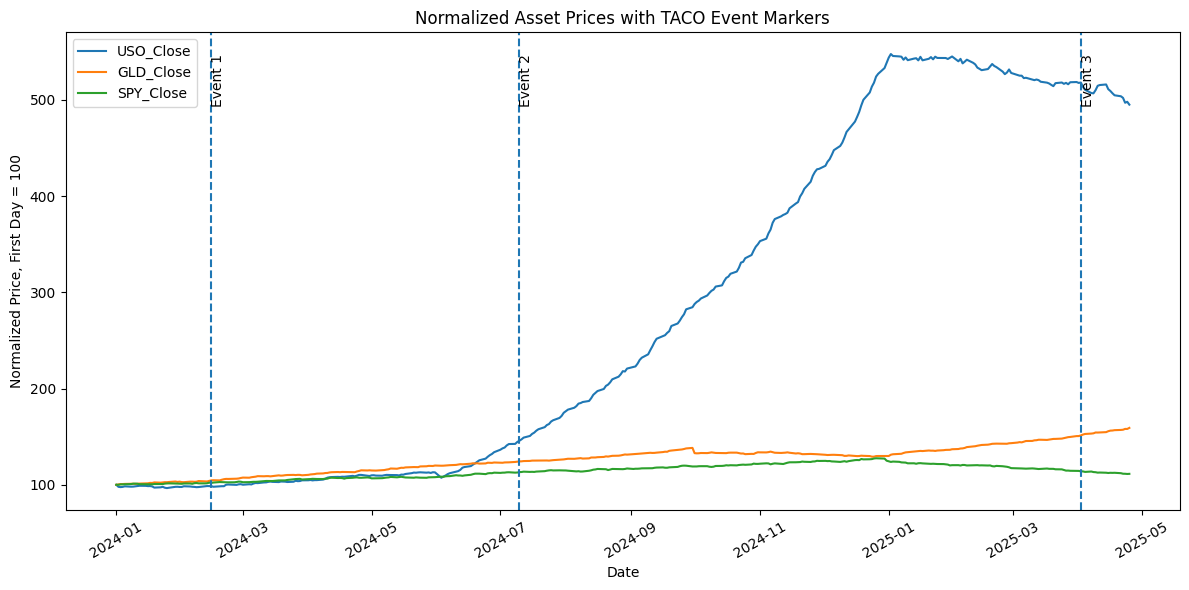


事件后涨跌幅统计：
      事件名称        事件日期       事件交易日    观察窗口        目标日期  USO涨跌幅%  GLD涨跌幅%  \
0  Event 1  2024-02-15  2024-02-15  1个交易日后  2024-02-16    -0.66     0.12   
1  Event 1  2024-02-15  2024-02-15  3个交易日后  2024-02-20    -0.07     0.62   
2  Event 1  2024-02-15  2024-02-15  5个交易日后  2024-02-22     1.47     1.46   
3  Event 2  2024-07-10  2024-07-10  1个交易日后  2024-07-11     1.00     0.06   
4  Event 2  2024-07-10  2024-07-10  3个交易日后  2024-07-15     3.43     0.41   
5  Event 2  2024-07-10  2024-07-10  5个交易日后  2024-07-17     5.77     0.69   
6  Event 3  2025-04-02  2025-04-02  1个交易日后  2025-04-03    -0.84     0.59   
7  Event 3  2025-04-02  2025-04-02  3个交易日后  2025-04-07    -2.11     1.28   
8  Event 3  2025-04-02  2025-04-02  5个交易日后  2025-04-09    -1.53     2.02   

   SPY涨跌幅%  
0     0.38  
1     0.79  
2     0.56  
3     0.08  
4     0.17  
5     0.14  
6    -0.09  
7    -0.20  
8    -0.82  


In [7]:
# ==============================
# TACO 第三次课 综合案例
# 多资产归一化 + 事件标注 + 事件后涨跌幅
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# 1. 读取本地市场数据
# ------------------------------

df = pd.read_csv("market_data_2018_2025.csv", parse_dates=["date"])
df = df.set_index("date")

# 只看 2024 年之后的数据，让图表更清楚
df_recent = df[df.index >= "2024-01-01"]

# 选择资产
price_df = df_recent[["USO_Close", "GLD_Close", "SPY_Close"]].dropna()

# ------------------------------
# 2. 归一化处理
# ------------------------------

price_norm = price_df / price_df.iloc[0] * 100

# ------------------------------
# 3. 准备事件
# ------------------------------

# 这里使用示例日期
# 真实项目中应替换成老师提供或自己查找的 TACO 事件日期
events = {
    "Event 1": "2024-02-15",
    "Event 2": "2024-07-10",
    "Event 3": "2025-04-02"
}

# ------------------------------
# 4. 绘制多资产归一化图
# ------------------------------

plt.figure(figsize=(12, 6))

for column in price_norm.columns:
    plt.plot(price_norm.index, price_norm[column], label=column)

# 标注事件日期
for event_name, event_date in events.items():
    event_date = pd.to_datetime(event_date)

    plt.axvline(x=event_date, linestyle="--")

    plt.text(
        event_date,
        price_norm.max().max(),
        event_name,
        rotation=90,
        verticalalignment="top"
    )

plt.title("Normalized Asset Prices with TACO Event Markers")
plt.xlabel("Date")
plt.ylabel("Normalized Price, First Day = 100")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ------------------------------
# 5. 计算事件后涨跌幅
# ------------------------------

windows = [1, 3, 5]
results = []

for event_name, event_date in events.items():
    event_date = pd.to_datetime(event_date)

    # 找到事件日期之后最近的交易日
    future_dates = price_df.index[price_df.index >= event_date]

    if len(future_dates) == 0:
        print(f"{event_name} 没有可用数据，跳过。")
        continue

    event_trade_date = future_dates[0]
    base_prices = price_df.loc[event_trade_date]
    event_position = price_df.index.get_loc(event_trade_date)

    for window in windows:
        target_position = event_position + window

        if target_position >= len(price_df):
            continue

        target_date = price_df.index[target_position]
        target_prices = price_df.iloc[target_position]

        changes = (target_prices - base_prices) / base_prices * 100

        results.append({
            "事件名称": event_name,
            "事件日期": event_date.date(),
            "事件交易日": event_trade_date.date(),
            "观察窗口": f"{window}个交易日后",
            "目标日期": target_date.date(),
            "USO涨跌幅%": round(changes["USO_Close"], 2),
            "GLD涨跌幅%": round(changes["GLD_Close"], 2),
            "SPY涨跌幅%": round(changes["SPY_Close"], 2)
        })

result_df = pd.DataFrame(results)

print("\n事件后涨跌幅统计：")
print(result_df)